# Linear Regression Architecture Workshop — Part 1: Data Sourcing & EDA

This notebook demonstrates the three required data-source types: CSV files, web APIs, and a relational database (SQLite). It then performs basic exploratory data analysis (EDA).

## 1. Import Libraries

In [29]:
from pathlib import Path
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", message=".*NotOpenSSLWarning.*")

RAW_DATA = Path('../data/raw')
DB_PATH = Path('../data/housing_data.sqlite')

## 2. California Housing — CSV

Source: Kaggle California Housing Prices dataset.

In [2]:
california = pd.read_csv(RAW_DATA / 'california_housing.csv')
california.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [27]:
california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
california.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
print('Missing values:')
print(california.isna().sum())
print('\nDuplicate rows:', california.duplicated().sum())

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate rows: 0


## 3. Toronto Property Prices — CSV

Source: Kaggle Greater Toronto Area property dataset.

In [6]:
toronto = pd.read_csv(RAW_DATA / 'toronto_property_prices.csv')
toronto.head()

,price,region,address,bedrooms,bathrooms,pricem
0,799000,"Ajax, ON","2 ROLLO DR, Ajax, Ontario",3,3,0.799000
1,989000,"Ajax, ON","717 OLD HARWOOD AVE, Ajax, Ontario",2,1,0.989000
2,999900,"Ajax, ON","52 ADDLEY CRES, Ajax, Ontario",3,4,0.999900
3,799900,"Ajax, ON","249 MONARCH AVE, Ajax, Ontario",3,3,0.799900
4,899999,"Ajax, ON","18 MONK CRES, Ajax, Ontario",3,3,0.899999


In [28]:
toronto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7324 entries, 0 to 7323
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      7324 non-null   int64  
 1   region     7324 non-null   object 
 2   address    7324 non-null   object 
 3   bedrooms   7324 non-null   int64  
 4   bathrooms  7324 non-null   int64  
 5   pricem     7324 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 343.4+ KB


In [8]:
toronto.select_dtypes(include='number').describe()


,price,bedrooms,bathrooms,pricem
count,7.324000e+03,7324.000000,7324.000000,7324.000000
mean,1.444227e+06,3.062125,2.976106,1.444227
std,1.347525e+06,1.087886,1.401255,1.347525
min,3.590000e+05,0.000000,0.000000,0.359000
25%,7.997942e+05,2.000000,2.000000,0.799794
50%,1.099000e+06,3.000000,3.000000,1.099000
75%,1.599999e+06,4.000000,4.000000,1.599999
max,2.797500e+07,9.000000,15.000000,27.975000


In [9]:
print('Missing values:')
print(toronto.isna().sum())
print('\nDuplicate rows:', toronto.duplicated().sum())

Missing values:
price        0
region       0
address      0
bedrooms     0
bathrooms    0
pricem       0
dtype: int64

Duplicate rows: 1


## 4. California Open Data — API

The California Open Data portal provides a CKAN datastore API for APR Table A2. We request a small sample through the API rather than loading the full 189 MB CSV.

In [ ]:
CA_API_URL = (
    'https://data.ca.gov/api/action/datastore_search'
    '?resource_id=fe505d9b-8c36-42ba-ba30-08bc4f34e022&limit=100'
)

ca_response = requests.get(CA_API_URL, timeout=30)
ca_response.raise_for_status()
ca_json = ca_response.json()
california_api = pd.DataFrame(ca_json['result']['records'])

print('API status:', ca_response.status_code)
print('Rows retrieved:', len(california_api))
california_api.head()

california_api.to_csv(RAW_DATA / 'california_api_sample.csv', index=False)
print('Saved:', RAW_DATA / 'california_api_sample.csv')


API status: 200
Rows retrieved: 100
Saved: ../data/raw/california_api_sample.csv


In [29]:
california_api.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 70 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   _id                                    100 non-null    int64 
 1   JURIS_NAME                             100 non-null    object
 2   CNTY_NAME                              100 non-null    object
 3   YEAR                                   100 non-null    object
 4   PRIOR_APN                              0 non-null      object
 5   APN                                    100 non-null    object
 6   STREET_ADDRESS                         100 non-null    object
 7   PROJECT_NAME                           80 non-null     object
 8   JURS_TRACKING_ID                       62 non-null     object
 9   UNIT_CAT                               100 non-null    object
 10  TENURE                                 100 non-null    object
 11  ACUTELY_LOW_INCOME_D

In [12]:
california_api.select_dtypes(include='number').describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
_id,100.0,50.5,29.011492,1.0,25.75,50.5,75.25,100.0


In [13]:
california_api.isna().sum().sort_values(ascending=False).head(15)

DR_TYPE                            100
TERM_AFF_DR                        100
PRIOR_APN                          100
FIN_ASSIST_NAME                    100
DENSITY_BONUS_RECEIVE_REDUCTION    100
DENSITY_BONUS_INCENTIVES           100
ENT_APPROVE_DT1                     96
CO_ISSUE_DT1                        74
NOTES                               69
JURS_TRACKING_ID                    38
STD_ADDRESS                         23
BP_ISSUE_DT1                        21
PROJECT_NAME                        20
DENSITY_BONUS_TOTAL                  0
NO_OTHER_FORMS_OF_READINESS          0
dtype: int64

## 5. Toronto Open Data — API

The Toronto Open Data portal uses a CKAN API. We first request the dataset metadata, then identify the 2021 Neighbourhood Profiles resource and download it through its resource URL.

In [14]:
TORONTO_API_URL = (
    'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/package_show'
    '?id=neighbourhood-profiles'
)

toronto_response = requests.get(TORONTO_API_URL, timeout=30)
toronto_response.raise_for_status()
toronto_package = toronto_response.json()

print('API status:', toronto_response.status_code)
print('Dataset:', toronto_package['result']['title'])

API status: 200
Dataset: Neighbourhood Profiles


In [15]:
# Find the 2021 census profile resource.
resources = toronto_package['result']['resources']
profile_resources = [
    r for r in resources
    if '2021' in (r.get('name') or '').lower()
    and 'metadata' not in (r.get('name') or '').lower()
]
[(r.get('name'), r.get('format'), r.get('url')) for r in profile_resources]

[('neighbourhood-profiles-2021-158-model',
  'XLSX',
  'https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/6e19a90f-971c-46b3-852c-0c48c436d1fc/resource/19d4a806-7385-4889-acf2-256f1e079060/download/nbhd_2021_census_profile_full_158model.xlsx')]

In [16]:
from io import BytesIO

# Load the 2021 profile directly from the official Toronto Open Data resource.
profile_resource = profile_resources[0]
profile_url = profile_resource['url']
profile_response = requests.get(profile_url, timeout=60)
profile_response.raise_for_status()

content_type = profile_response.headers.get('Content-Type', '').lower()
if 'excel' in content_type or profile_url.lower().endswith(('.xlsx', '.xls')):
    toronto_neighbourhood = pd.read_excel(BytesIO(profile_response.content))
else:
    toronto_neighbourhood = pd.read_csv(BytesIO(profile_response.content))

print('Resource:', profile_resource['name'])
print('Rows loaded:', len(toronto_neighbourhood))
toronto_neighbourhood.head()

# Save the retrieved Toronto API data for reproducibility.
toronto_neighbourhood.to_csv(RAW_DATA / 'toronto_neighbourhood_api.csv', index=False)
print('Saved:', RAW_DATA / 'toronto_neighbourhood_api.csv')


Resource: neighbourhood-profiles-2021-158-model
Rows loaded: 2603
Saved: ../data/raw/toronto_neighbourhood_api.csv


In [17]:
print('Shape:', toronto_neighbourhood.shape)
toronto_neighbourhood.info()

Shape: (2603, 159)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2603 entries, 0 to 2602
Columns: 159 entries, Neighbourhood Name to South Eglinton-Davisville
dtypes: object(159)
memory usage: 3.2+ MB


In [18]:
# The profile is supplied with neighbourhoods as columns and profile variables as rows.
toronto_neighbourhood.iloc[:10, :8]

,Neighbourhood Name,West Humber-Clairville,Mount Olive-Silverstone-Jamestown,Thistletown-Beaumond Heights,Rexdale-Kipling,Elms-Old Rexdale,Kingsview Village-The Westway,Willowridge-Martingrove-Richview
0,Neighbourhood Number,1,2,3,4,5,6,7
1,TSNS 2020 Designation,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood
2,Total - Age groups of the population - 25% sam...,33300,31345,9850,10375,9355,22005,22445
3,0 to 14 years,4295,5690,1495,1575,1610,3915,3500
4,0 to 4 years,1460,1650,505,505,440,1245,1065
5,5 to 9 years,1345,1860,540,615,480,1325,1190
6,10 to 14 years,1485,2175,455,455,685,1350,1240
7,15 to 64 years,23640,21490,6615,6950,6355,14385,13865
8,15 to 19 years,1860,2280,570,515,635,1245,1175
9,20 to 24 years,3175,2675,745,715,685,1605,1330


## 6. SQLite Database

The SQLite database contains copies of the two property-oriented CSV datasets so that we can demonstrate SQL selection/filtering.

In [30]:
connection = sqlite3.connect(DB_PATH)
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    connection
)
tables

,name
0,california_housing
1,toronto_properties


In [20]:
california_db = pd.read_sql_query(
    "SELECT * FROM california_housing LIMIT 5;",
    connection
)
california_db

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [21]:
toronto_db = pd.read_sql_query(
    "SELECT * FROM toronto_properties LIMIT 5;",
    connection
)
toronto_db

,price,region,address,bedrooms,bathrooms,pricem
0,799000,"Ajax, ON","2 ROLLO DR, Ajax, Ontario",3,3,0.799000
1,989000,"Ajax, ON","717 OLD HARWOOD AVE, Ajax, Ontario",2,1,0.989000
2,999900,"Ajax, ON","52 ADDLEY CRES, Ajax, Ontario",3,4,0.999900
3,799900,"Ajax, ON","249 MONARCH AVE, Ajax, Ontario",3,3,0.799900
4,899999,"Ajax, ON","18 MONK CRES, Ajax, Ontario",3,3,0.899999


In [22]:
connection.close()

## 7. Basic Visualizations

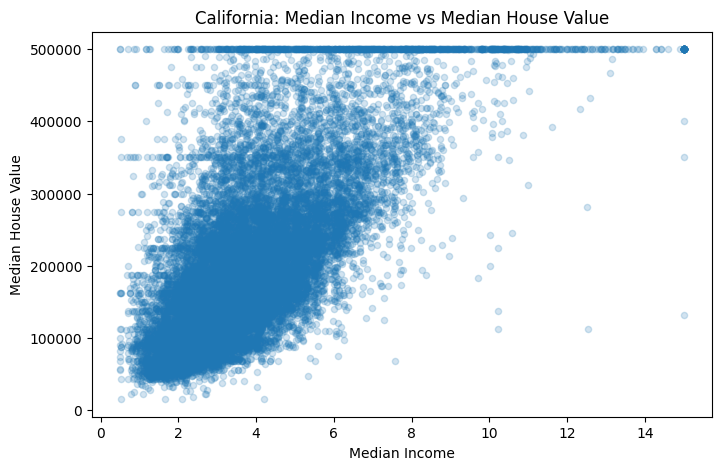

In [23]:
california.plot.scatter(
    x='median_income', y='median_house_value', alpha=0.2, figsize=(8, 5)
)
plt.title('California: Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

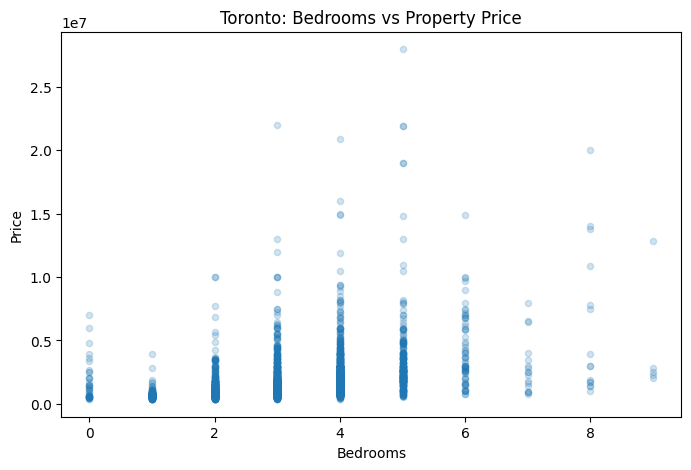

In [24]:
toronto.plot.scatter(
    x='bedrooms', y='price', alpha=0.2, figsize=(8, 5)
)
plt.title('Toronto: Bedrooms vs Property Price')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

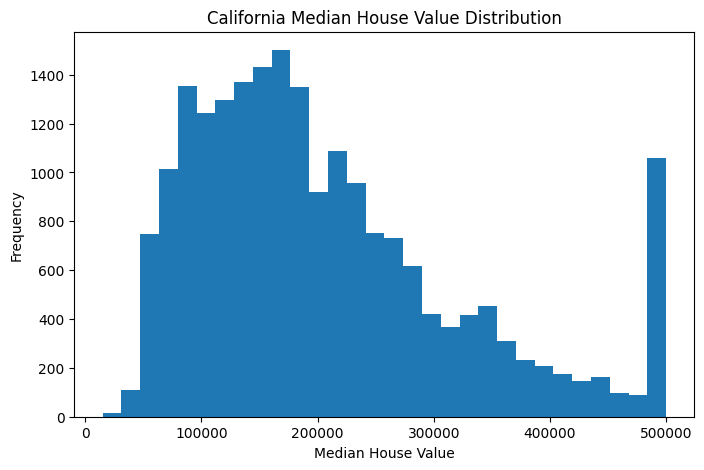

In [25]:
california['median_house_value'].plot(kind='hist', bins=30, figsize=(8, 5))
plt.title('California Median House Value Distribution')
plt.xlabel('Median House Value')
plt.show()

## 8. Initial Observations

- The California CSV contains a direct house-value variable (`median_house_value`) and several numerical housing predictors.
- The Toronto property CSV contains property prices and bedroom/bathroom information.
- The California government APR API contains housing development/progress information reported by jurisdictions.
- The Toronto Neighbourhood Profiles API provides neighbourhood-level demographic, social, economic, and housing information based on Census data.
- The datasets describe different aspects of housing, so they should not be treated as if they measure the same target.

## 9. Modeling Variables and Preprocessing

### Target Variable

The target variable selected for the regression model is `median_house_value` from the California housing CSV dataset.

### Single Predictor

The single predictor selected for the regression model is `median_income`. It is a numerical variable and is suitable for univariate linear regression against `median_house_value`.

### Preprocessing Considerations

- The California dataset contains missing values in `total_bedrooms`.
- The selected predictor (`median_income`) and target (`median_house_value`) do not require missing-value treatment based on the EDA.
- The selected predictor may be standardized during the modeling stage if required by the implementation.

### EDA Findings

- The California dataset contains 20,640 rows and 10 columns.
- `median_house_value` is the selected housing-price target.
- `median_income` is the selected numerical predictor.
- The scatter plot provides a visual view of the relationship between median income and median house value.
- The median house value histogram shows the distribution of the selected target variable.
- The Toronto property data provides an additional housing-price dataset for EDA and comparison.
- The API datasets demonstrate retrieval of housing/open-data information through web services.
